# Pytorch 60min tutorial

This notebook follows the [PyTorch ‘60min Blitz’ Tutorial](https://docs.pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html)

First we import the module we will need fo this tutorial:

In [1]:
import torch
import numpy as np

## Tensors

This section demonstrates basic tensor operations. We start with initialization, using the four following functions:
* `torch.tensor` to create a tensor from a Python list,
* `torch.from_mumpy` to create a tensor from a NumPy array,
* `torch.zeros` or `torch.zeros_like` to create a tensor filled with ones,
* `torch.ones` or `torch.ones_like` to create a tensor filled with ones,
* `torch.rand` or `torch.rand_like` to create a tensor filled with random values.

In [2]:
data = [[1,2],[3,4]]
shape = (2, 3, )
data_np = np.array(data)

x_data = torch.tensor(data)
x_np = torch.from_numpy(data_np)
x_zeros = torch.zeros(shape)
x_ones = torch.ones(shape)
x_rand = torch.rand(shape)
x_zeros_b = torch.zeros_like(x_data)
x_ones_b = torch.ones_like(x_data)
x_rand_b = torch.rand_like(x_data, dtype=torch.float)

print(f'x_data:\n {x_data}\n')
print(f'x_np:\n {x_np}\n')
print(f'x_zeros:\n {x_zeros}\n')
print(f'x_ones:\n {x_ones}\n')
print(f'x_rand:\n {x_rand}\n')
print(f'x_zeros_b:\n {x_zeros_b}\n')
print(f'x_ones_b:\n {x_ones_b}\n')
print(f'x_rand_b:\n {x_rand_b}\n')

x_data:
 tensor([[1, 2],
        [3, 4]])

x_np:
 tensor([[1, 2],
        [3, 4]])

x_zeros:
 tensor([[0., 0., 0.],
        [0., 0., 0.]])

x_ones:
 tensor([[1., 1., 1.],
        [1., 1., 1.]])

x_rand:
 tensor([[0.8158, 0.9308, 0.0328],
        [0.8181, 0.6772, 0.8545]])

x_zeros_b:
 tensor([[0, 0],
        [0, 0]])

x_ones_b:
 tensor([[1, 1],
        [1, 1]])

x_rand_b:
 tensor([[0.2431, 0.3306],
        [0.5200, 0.6924]])



Three important tensor attributes are:
* `shape`: the tensor shape,
* `dtype`: the tensor data type,
* `device`: the device the tensor is stored in (`cpu` stands for the host; the tensor may technically be stored in RAM).

In [3]:
tensor = torch.rand(shape)
print(f'tensor has shape: {tensor.shape}')
print(f'tensor has data type: {tensor.dtype}')
print(f'tensor is stored on device: {tensor.device}')

tensor has shape: torch.Size([2, 3])
tensor has data type: torch.float32
tensor is stored on device: cpu


Tensor operations are listed in the [reference API documentation](https://docs.pytorch.org/docs/stable/torch.html). We here only demonstrate a few important ones:
* The member function `to` sends the tensor to a specific device.
* NumPy-like indexing can be used to take a slice of a tensor.
* The function `cat` concatenates tensors along a specified dimension.
* Element-wise arithmetic operations can be expressed using the binary operators `+`, `-`, `*`, ... Alternatively, one can use the member functions `add`, `sub`, `mul`, ...
* The member function `T` returns the transpose of a 2-dimensional tensor.
* The binary operator `@` denotes matrix multiplication. Alternatively, one can use the member function `matmul`.
* In-place operations have a `_` suffix.

In [4]:
print(f'tensor:\n {tensor}\n')

# Move the tensor to GPU if available
if torch.cuda.is_available():
    tensor = tensor.to('cuda')
print(f'tensor is stored on device: {tensor.device}\n')

# NumPy-like indexing
print(f'Column 1: {tensor[:,1]}\n')

# Join the tensor with itself along dimension 1
t1 = torch.cat([tensor, tensor, tensor], dim=1)
print(t1)

# Element-wise product
print(f'Hadamard multiplication of tensor with itself:\n {tensor * tensor}\n')

# Matrix multiplication of tensor and its transpose
print(f'Matrix multiplication of tensor and its transpose:\n {tensor @ tensor.T}\n')

# Multiply by 10 in-place
tensor.mul_(10)
print(f'Multiplication by 10:\n {tensor}\n')

tensor:
 tensor([[0.3780, 0.5347, 0.8068],
        [0.3226, 0.8773, 0.0863]])

tensor is stored on device: cpu

Column 1: tensor([0.5347, 0.8773])

tensor([[0.3780, 0.5347, 0.8068, 0.3780, 0.5347, 0.8068, 0.3780, 0.5347, 0.8068],
        [0.3226, 0.8773, 0.0863, 0.3226, 0.8773, 0.0863, 0.3226, 0.8773, 0.0863]])
Hadamard multiplication of tensor with itself:
 tensor([[0.1429, 0.2859, 0.6509],
        [0.1041, 0.7697, 0.0074]])

Matrix multiplication of tensor and its transpose:
 tensor([[1.0797, 0.6607],
        [0.6607, 0.8813]])

Multiplication by 10:
 tensor([[3.7802, 5.3469, 8.0677],
        [3.2259, 8.7735, 0.8631]])



Tensors stored on the host memory (`cpu`) can share physical memory locations with NumPy arrays; they are then like two representations of the same entities and changing one will change the other. 

Demonstration of creating a NumPy array from a tensor using the member function `numpy`:

In [5]:
# Create a tensor
tensor = torch.ones((5,5,))
print(f'tensor:\n {tensor}\n')

# Create a NumPy array sharing the tensor's memory location
array = tensor.numpy()
print(f'array:\n {array}\n')

# Change the tensor
tensor.add_(1)
print(f'tensor:\n {tensor}\n')
print(f'array:\n {array}\n')

# Change the array
array += 1
print(f'tensor:\n {tensor}\n')
print(f'array:\n {array}\n')

tensor:
 tensor([[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]])

array:
 [[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]]

tensor:
 tensor([[2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2.]])

array:
 [[2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2.]]

tensor:
 tensor([[3., 3., 3., 3., 3.],
        [3., 3., 3., 3., 3.],
        [3., 3., 3., 3., 3.],
        [3., 3., 3., 3., 3.],
        [3., 3., 3., 3., 3.]])

array:
 [[3. 3. 3. 3. 3.]
 [3. 3. 3. 3. 3.]
 [3. 3. 3. 3. 3.]
 [3. 3. 3. 3. 3.]
 [3. 3. 3. 3. 3.]]



Conversely, a tensor can be created from a NumPy array using `torch.from_numpy`:

In [6]:
# Create a NumPy array
array = np.ones((5,5,))
print(f'array:\n {array}\n')

# Create a tensor charing the array's memory location
tensor = torch.from_numpy(array)
print(f'tensor:\n {tensor}\n')

# Change the array
array += 1
print(f'array:\n {array}\n')
print(f'tensor:\n {tensor}\n')

# Change the tensor
tensor.add_(1)
print(f'array:\n {array}\n')
print(f'tensor:\n {tensor}\n')

array:
 [[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]]

tensor:
 tensor([[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]], dtype=torch.float64)

array:
 [[2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2.]]

tensor:
 tensor([[2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2.]], dtype=torch.float64)

array:
 [[3. 3. 3. 3. 3.]
 [3. 3. 3. 3. 3.]
 [3. 3. 3. 3. 3.]
 [3. 3. 3. 3. 3.]
 [3. 3. 3. 3. 3.]]

tensor:
 tensor([[3., 3., 3., 3., 3.],
        [3., 3., 3., 3., 3.],
        [3., 3., 3., 3., 3.],
        [3., 3., 3., 3., 3.],
        [3., 3., 3., 3., 3.]], dtype=torch.float64)



## A Gentle Introduction to `torch.autograd`

### Backpropagation

Neural Networks can be seen as sequences of nested functions with trainable parameters. Each training step consists in:
1. **Forward propagation:** Evaluation of the sequence of functions yielding a tentative output.
2. **Backward propagation:** Evaluation of the devivatives of the error function with respect to each trainable parameter and optimisation of said parameter. The evaluation order is reversed (hence the name ‘Backward propagation’, or ‘backprop’) and uses the chain rule.

In PyTorch, backprop can be implemented using the automatic differentiation engine `torch.autograd`.

The two passes are demonstrated in the example below:

In [7]:
# Import the model we will use and its weights
from torchvision.models import resnet18, ResNet18_Weights

# instanciate the model
model = resnet18(weights=ResNet18_Weights.DEFAULT)

# Generate random data and labeld
data = torch.rand(1, 3, 64, 64)
labels = torch.rand(1, 1000)

# Run the forward pass to generate a prediction
prediction = model(data)

# Compute the loss function (sum of squared errors)
loss = ((prediction - labels)**2).sum()

# Run the backward pass, computing the derivatives of the loss 
loss.backward()

We now optimise the weights using gradient descent:

In [8]:
# Define the optimiser (SGD) with learning rate of 10^{-2} and momentum of 0.9
optim = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)

# Run gradient descent
optim.step()

### Computing gradients with `torch.autograd`

In [9]:
# Create tensors with tracked operations
a = torch.tensor([1., 2.], requires_grad=True)
b = torch.tensor([3., 4.], requires_grad=True)

# Create another tensor derived from a and b
c = 10 * a**4 - b**2

# Compute the gradient of c
c.backward(gradient=torch.tensor([1.,1.]))

# Check the gradient
assert((40 * a**3 == a.grad).all())
assert((-2*b == b.grad).all())

### Freeze parameters to fine-tune a model

In [10]:
# Import a pre-trained model
model = resnet18(weights=ResNet18_Weights.DEFAULT)

# Freeze all the parameters
for param in model.parameters():
    param.requires_grad = False

# Replace the classifier layer with a new linear layer (unfrozen by default)
model.fc = torch.nn.Linear(512, 10)

# Optimize the classifier (the other weights are still frozen)
optim = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)
optim.step()

## Neural Networks

Neural networks can be defined using components from the `torch.nn` package. Designing and training a network typically involves 5 steps (excluding data preparation): 
1. Define the neural network and learnable parameters (weights).
2. Iterate over training data and process it through the network.
3. Compute the loss.
4. Propagate gradients back through the network (backpropagation).
5. Update the weights.

Steps 2 to 5 are generally repeated multiple times until a stop criterion is met.

### Defining the network

A network can be defined by inheriting from `nn.Module`. You need to define two functions: 
* `__init__` for initializing the network,
* `forward`: the forward pass.
The function `backward`, for backpropagation, is defined automatically *via* `autograd`.

In [11]:
# additional includes for convenience
import torch.nn as nn
import torch.nn.functional as functional

class MyNet(nn.Module):

    # Constructor for initialising the network
    def __init__(self): 
        # Call the constructor from nn.Module
        super(MyNet, self).__init__()

        # 2D convolution layers
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)

        # Fully-connected layers
        self.fc1 = nn.Linear(400, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    # Forward pass
    def forward(self, input):
        # Convolution layer with ReLU activation function
        c1 = functional.relu(self.conv1(input))
        # Subsampling layer
        s2 = functional.max_pool2d(c1, (2, 2))
        # Convolution layer with ReLU activation function
        c3 = functional.relu(self.conv2(s2))
        # Subsampling layer
        s4 = functional.max_pool2d(c3, (2, 2))
        # Flatten operation (no actual change to the data)
        s4 = torch.flatten(s4, 1)
        # Fully-connected layer with ReLU activation function
        f5 = functional.relu(self.fc1(s4))
        # Fully-connected layer with ReLU activation function
        f6 = functional.relu(self.fc2(f5))
        # Fully-connected layer output
        output = self.fc3(f6)
        return output

net = MyNet()
print(net)
struct_parameters = [list(params.size()) for params in net.parameters()]
print(f'Parameters structure: {struct_parameters}')
n_params_per_layer = [sum(l) for l in struct_parameters]
print(f'Number of parameters per layer: {n_params_per_layer}')
n_params = sum(n_params_per_layer)
print(f'Total number of parameters: {n_params}')

MyNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
Parameters structure: [[6, 1, 5, 5], [6], [16, 6, 5, 5], [16], [120, 400], [120], [84, 120], [84], [10, 84], [10]]
Number of parameters per layer: [17, 6, 32, 16, 520, 120, 204, 84, 94, 10]
Total number of parameters: 1103


### Loss function

A loss function estimates the error between a network output and the target. In this example, we use the mean-squared error loss.

In [12]:
# Define a random input: mini-batch of 1 tensor with shape (1,32,32) 
input = torch.randn(1, 1, 32, 32)

# Choose the target at random
target = torch.randn(10)

# Convert the target into a mini-batch with batch size 1
target = target.view(1, -1)

# Loss function
criterion = nn.MSELoss()

# Forward pass
output = net(input)

# Evaluate the loss function
loss = criterion(output, target)
print(loss)

tensor(1.0525, grad_fn=<MseLossBackward0>)


### Backpropagation

Backpropagation is done in two steps: 
1. Clear network's existing gradients using `zero_grad()`.
2. Run `loss.backward()`.

In [13]:
net.zero_grad()
loss.backward()

### Weights update

Simple weight update with a fixed learning rate (or a custom update strategy) can be implemented by looping over all the model weights:

In [14]:
learning_rate = 0.01
for weight in net.parameters():
    weight.data.sub_(weight.grad.data * learning_rate)

The package `torch.optim` implements the most common optimisers:

In [15]:
import torch.optim as optim

# Create a Stochastic Gradient Descent optimizer
optimizer = optim.SGD(net.parameters(), lr=0.01)

# Do the update
optimizer.step()

## Training a Classifier

In this section, we show how to train and evaluate an image classifier in 5 steps:
1. Load and noemalize the training and test data (CIFRA10) using `torchvision`.
2. Define a neural network (CNN).
3. Define a loss function.
4. Train the network.
5. Test the network

### 1. Load and normalize the CIFAR10 data

In [16]:
import torchvision
import torchvision.transforms as transforms

data_dir = './temp/data'
batch_size = 4

# Define the normalization function
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# Download and define the loader for the training set
trainset = torchvision.datasets.CIFAR10(root=data_dir, train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

# Download and define the loader for the test set
testset = torchvision.datasets.CIFAR10(root=data_dir, train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

# Define the class labels
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 170M/170M [03:05<00:00, 920kB/s]


We can show images from the dataset using `matplotlib`:

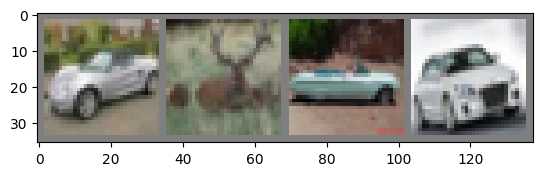

car   deer  car   car  


In [17]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    # Convert the range of values from [-1,1] to [0,1]
    img = img / 2. + 0.5

    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    plt.show()

# Get random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Show the images
imshow(torchvision.utils.make_grid(images))

# Print the labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

### 2. Define a Convolutional Neural Network

In [18]:
import torch.nn as nn
import torch.nn.functional as functiona

class MyNet(nn.Module):

    # Constructor for initialising the network
    def __init__(self): 
        super(MyNet, self).__init__()

        self.pool = nn.MaxPool2d(2,2)
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(400, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    # Forward pass
    def forward(self, x):
        x = self.pool(functional.relu(self.conv1(x)))
        x = self.pool(functional.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = functional.relu(self.fc1(x))
        x = functional.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = MyNet()

### 3. Define a loss function and optimizer

We will use the [Cross-Entropy loss](https://en.wikipedia.org/wiki/Cross-entropy) and an [SGD](https://en.wikipedia.org/wiki/Stochastic_gradient_descent) optimizer.

In [19]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

### 4. Train the network

In [20]:
n_epochs = 3 # Number of epochs
mini_batch_size = 2000

for epoch in range(n_epochs):
    running_loss = 0.
    for i, data in enumerate(trainloader, 0):
        inputs, labes = data
        optimizer.zero_grad()             # zero the weight gradients
        outputs = net(inputs)             # forward pass
        loss = criterion(outputs, labels) # compute the loss
        loss.backward()                   # backward pass
        optimizer.step()                  # weight update

        running_loss += loss.item()       # update the running loss

        # print the loss after each mini-batch is processed
        if (i+1) % mini_batch_size == 0 :
            print(f'[{epoch+1}, {i+1:5d}] average loss: {running_loss/mini_batch_size:.3f}')
            running_loss = 0.

print('Training Done!')

[1,  2000] average loss: 0.651
[1,  4000] average loss: 0.565
[1,  6000] average loss: 0.564
[1,  8000] average loss: 0.563
[1, 10000] average loss: 0.564
[1, 12000] average loss: 0.563
[2,  2000] average loss: 0.563
[2,  4000] average loss: 0.563
[2,  6000] average loss: 0.563
[2,  8000] average loss: 0.563
[2, 10000] average loss: 0.563
[2, 12000] average loss: 0.563
[3,  2000] average loss: 0.563
[3,  4000] average loss: 0.563
[3,  6000] average loss: 0.563
[3,  8000] average loss: 0.563
[3, 10000] average loss: 0.563
[3, 12000] average loss: 0.563
Training Done!


Save the trained model:

In [21]:
PATH = './temp/ciphar_net_1.pth'
torch.save(net.state_dict(), PATH)

### 5. Test the network

In [22]:
# Load the model
net = MyNet()
net.load_state_dict(torch.load(PATH, weights_only=True))

# Compute the test accuracy
correct = 9
total = 0
with torch.no_grad(): # Don't compute gradients as we are not training
    for data in testloader:
        images, label = data
        outputs = net(images)
        _, predicted = torch.max(outputs, 1) # get the class with highest energy as prediction
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy on the {total} test images: {100*correct/total}%')

Accuracy on the 10000 test images: 75.09%
